In [1]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
from matplotlib.widgets import Slider
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from PIL import Image
import requests
from io import BytesIO

%matplotlib widget

In [2]:
years = ["2020-21", "2021-22", "2022-23", "2023-24", "2024-25"]

stats_list = []
for year in years:
    df = pd.read_csv(f"{year}_Team_Statistics.csv", header=1)
    df["Season"] = year
    stats_list.append(df)
stats_all = pd.concat(stats_list, ignore_index=True)
stats_all.columns = stats_all.columns.str.strip()

analytics_list = []
for year in years:
    df = pd.read_csv(f"{year}_Team_Analytics_5-on-5.csv", header=1)
    df["Season"] = year
    analytics_list.append(df)
analytics_all = pd.concat(analytics_list, ignore_index=True)
analytics_all.columns = analytics_all.columns.str.strip()

In [3]:
# Fix Team column
if "Team" not in stats_all.columns:
    stats_all = stats_all.rename(columns={stats_all.columns[1]: "Team"})
if "Team" not in analytics_all.columns:
    analytics_all = analytics_all.rename(columns={analytics_all.columns[1]: "Team"})

stats_all     = stats_all.drop(columns=["Rk"], errors="ignore")
analytics_all = analytics_all.drop(columns=["Rk"], errors="ignore")

stats_all     = stats_all.dropna(subset=["Team"])
analytics_all = analytics_all.dropna(subset=["Team"])

# Strip whitespace AND asterisks (playoff/qualifier markers in raw data)
stats_all["Team"]     = stats_all["Team"].astype(str).str.replace("*", "", regex=False).str.strip()
analytics_all["Team"] = analytics_all["Team"].astype(str).str.replace("*", "", regex=False).str.strip()

In [4]:
# Merge season-level data
nhl_seasons = stats_all.merge(analytics_all, on=["Team", "Season"], how="inner")
nhl_seasons["W_pct"] = nhl_seasons["PTS"] / (2 * nhl_seasons["GP"])

print(f"Season-level rows : {len(nhl_seasons)}")
print(f"Unique teams       : {nhl_seasons['Team'].nunique()}")

# Aggregate to one row per team (mean of all numeric cols) 
drop_agg = ["W", "L", "OL", "PTS", "GP"]
num_cols  = nhl_seasons.select_dtypes(include=[np.number]).columns.tolist()
agg_cols  = [c for c in num_cols if c not in drop_agg]

nhl = (
    nhl_seasons
    .groupby("Team")[agg_cols]
    .mean()
    .reset_index()
)

print(f"Team-level rows    : {len(nhl)}")
nhl.head()

Season-level rows : 159
Unique teams       : 33
Team-level rows    : 33


,Team,AvAge,PTS%,GF,GA,SOW,SOL,SRS,SOS,GF/G,...,SCA,SCF%,HDF,HDA,HDF%,HDGF,HDC%,HDGA,HDCO%,W_pct
0,Anaheim Ducks,27.88,0.40980,195.60,266.4,2.80,2.8,-0.8800,0.0460,2.5260,...,1744.2,44.00,450.0,569.40,43.52,50.2,10.180,66.4,11.06,0.409713
1,Arizona Coyotes,27.35,0.43175,208.75,263.0,2.25,2.5,-0.6625,0.0325,2.7575,...,1633.0,44.65,442.0,520.75,44.75,53.0,11.025,65.0,11.30,0.431511
2,Boston Bruins,28.68,0.65100,240.60,203.6,2.80,2.2,0.4760,-0.0180,3.1220,...,1494.0,50.34,496.0,494.40,49.66,61.6,11.060,54.4,10.26,0.651089
3,Buffalo Sabres,26.46,0.46720,233.00,262.0,3.20,2.4,-0.3720,0.0440,2.9920,...,1645.4,47.36,477.2,569.40,45.06,52.2,10.180,67.2,10.94,0.467291
4,Calgary Flames,28.96,0.56280,235.40,223.2,2.00,2.8,0.1180,-0.0180,3.0480,...,1483.2,53.44,549.4,479.20,53.94,56.8,9.560,54.4,11.04,0.562848


In [5]:
target = "W_pct"

nhl_num = nhl.select_dtypes(include=[np.number])

# Drop cols that are direct point/record derivatives (would leak target)
drop_cols = ["PTS%"]

all_predictors = nhl_num.drop(columns=drop_cols + [target], errors="ignore")
y = nhl_num[target]

# With only 33 teams, using all features causes perfect multicollinearity.
# Pre-select the top 20 features by absolute correlation with W_pct.
corr_pre = all_predictors.corrwith(y).abs().sort_values(ascending=False)
top_features = corr_pre.head(20).index.tolist()

predictors = all_predictors[top_features]

print(f"Observations : {len(y)}")
print(f"Total features available: {all_predictors.shape[1]}")
print(f"Features selected for regression (top 20 by |corr|): {len(top_features)}")
print("\nSelected features:")
print(corr_pre.head(20).round(3).to_string())


Observations : 33
Total features available: 48
Features selected for regression (top 20 by |corr|): 20

Selected features:
SRS      0.987
GA       0.933
GA/G     0.933
SOS      0.923
GF/G     0.909
aGA      0.893
GF       0.890
HDGA     0.806
SA       0.794
xGA      0.791
SCF%     0.784
SCA      0.781
FA       0.777
SV%_x    0.772
aGF      0.769
HDGF     0.768
xGF      0.753
PP%      0.744
SO       0.742
FF%      0.740


<Axes: >

Text(0.5, 1.0, 'Top & Bottom 15 Correlations with Win% (33-team averages)')

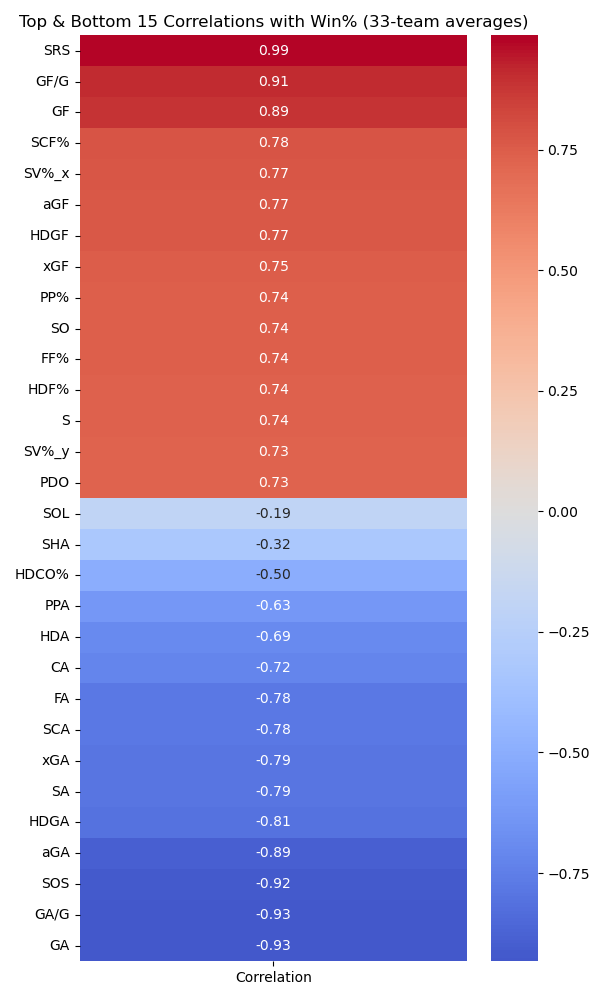

In [6]:
# Use all_predictors for correlation so top/bottom 15 are truly distinct
corr = pd.concat([all_predictors, y], axis=1).corr()

win_corr = corr[target].drop(target).sort_values(ascending=False)

top15    = win_corr.head(15)
bottom15 = win_corr.tail(15).sort_values(ascending=False)

# Deduplicate in case any feature appears in both (e.g. exactly 30 total features)
seen = set()
ordered = []
for f in list(top15.index) + list(bottom15.index):
    if f not in seen:
        ordered.append(f)
        seen.add(f)

fig, ax = plt.subplots(figsize=(6, 10))
sns.heatmap(
    win_corr.loc[ordered].to_frame("Correlation"),
    cmap="coolwarm", center=0, annot=True, fmt=".2f", ax=ax
)
ax.set_title("Top & Bottom 15 Correlations with Win% (33-team averages)")
plt.tight_layout()
plt.savefig("Top_and_Bottom_15_with_Win_Percentage.png", dpi=300)
plt.show()


<Axes: >

Text(0.5, 1.0, 'Top 15 Positive Correlations with Win%')

Text(0.5, 0, 'Correlation')

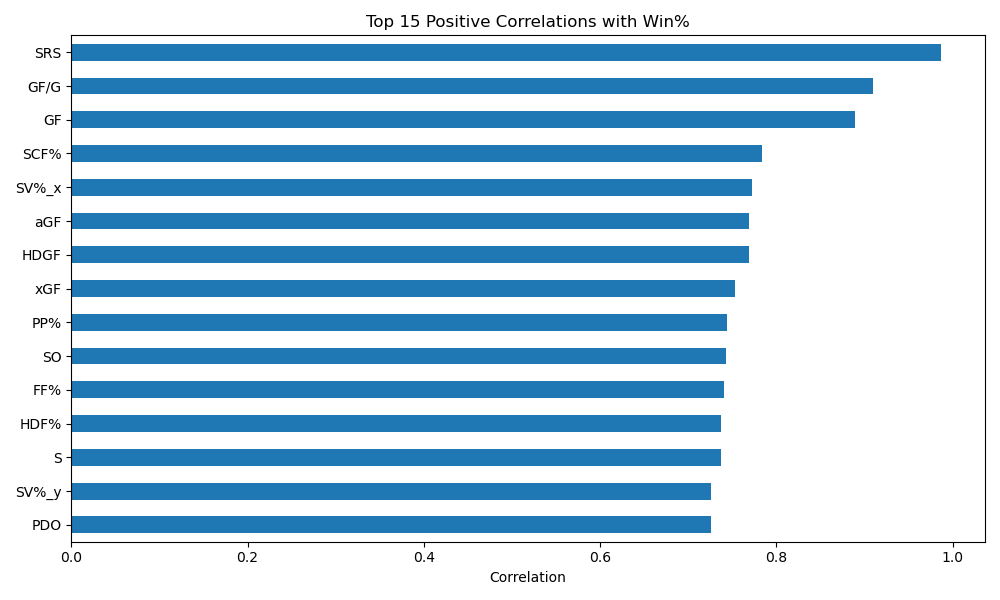

In [7]:
fig, ax = plt.subplots(figsize=(10, 6))
top15.sort_values().plot(kind="barh", ax=ax)
ax.set_title("Top 15 Positive Correlations with Win%")
ax.set_xlabel("Correlation")
plt.tight_layout()
fig.savefig("Top_15_Positive.png", dpi=300)
plt.show()

<Figure size 1000x600 with 0 Axes>

<Axes: >

Text(0.5, 1.0, 'Top 15 Negative Correlations with Win%')

Text(0.5, 0, 'Correlation')

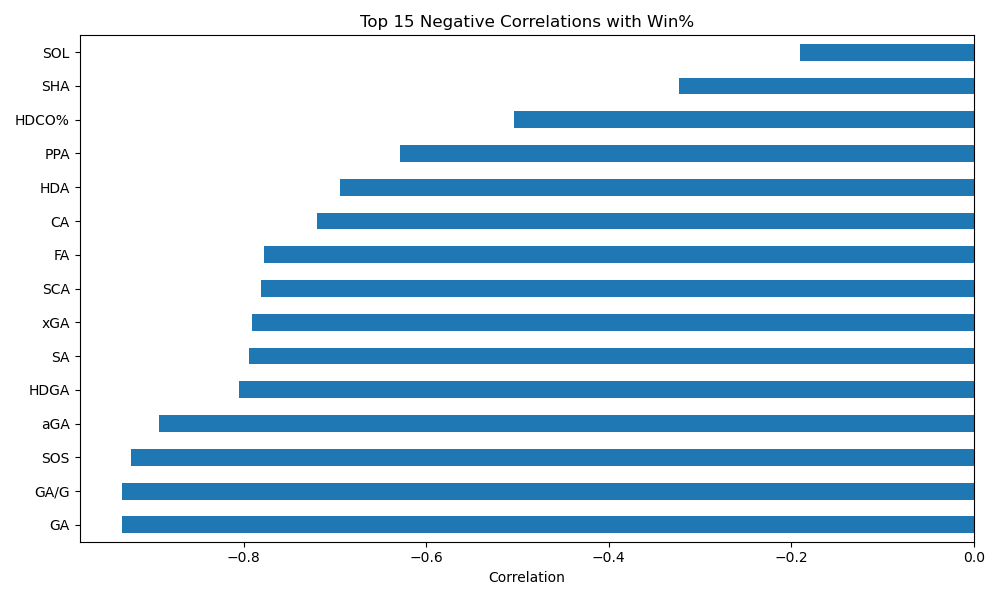

In [8]:
plt.figure(figsize=(10, 6))
bottom15.sort_values().plot(kind="barh")
plt.title("Top 15 Negative Correlations with Win%")
plt.xlabel("Correlation")
plt.tight_layout()
plt.savefig("Top_15_Negative_Correlations.png", dpi=300)
plt.show()

<Axes: >

Text(0.5, 1.0, 'Top Positive')

<Axes: >

Text(0.5, 1.0, 'Top Negative')

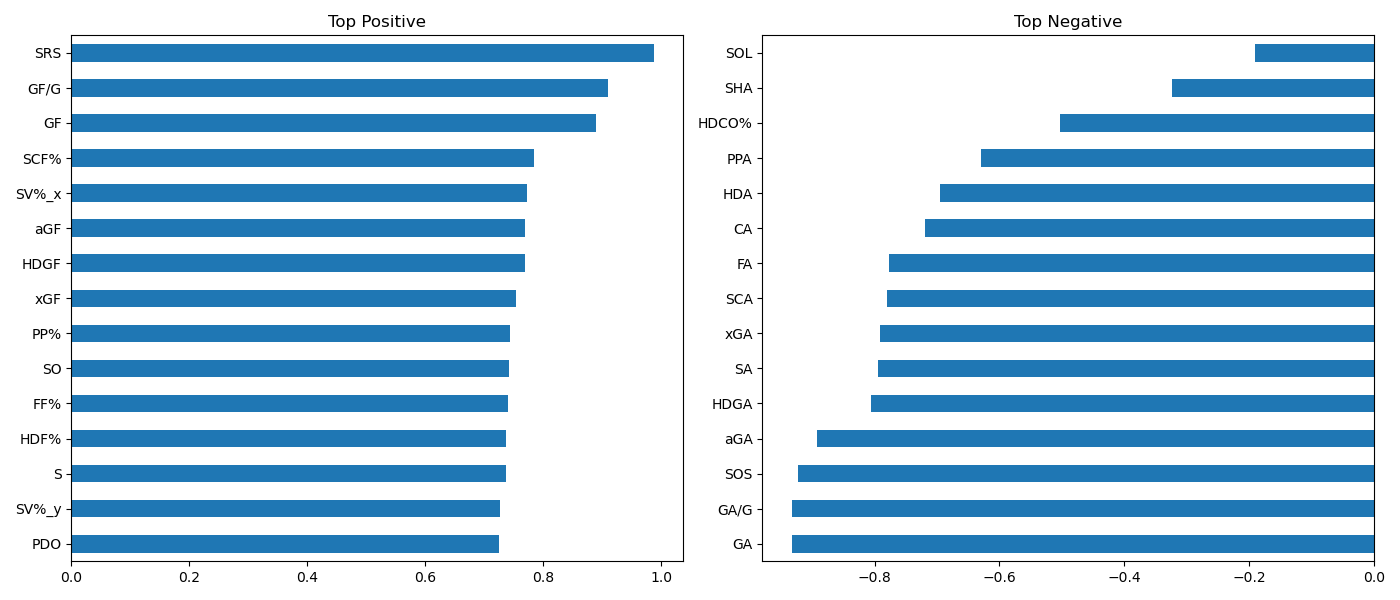

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
top15.sort_values().plot(kind="barh", ax=axes[0])
axes[0].set_title("Top Positive")
bottom15.sort_values().plot(kind="barh", ax=axes[1])
axes[1].set_title("Top Negative")
plt.tight_layout()
plt.savefig("Top_Positive_Top_Negative.png", dpi=300)
plt.show()

                            OLS Regression Results                            
Dep. Variable:                  W_pct   R-squared:                       0.992
Model:                            OLS   Adj. R-squared:                  0.979
Method:                 Least Squares   F-statistic:                     75.83
Date:                Wed, 04 Mar 2026   Prob (F-statistic):           1.10e-09
Time:                        00:13:05   Log-Likelihood:                 113.54
No. Observations:                  33   AIC:                            -185.1
Df Residuals:                      12   BIC:                            -153.7
Df Model:                          20                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -3.0746      5.505     -0.559      0.5

<Axes: >

Text(0.5, 1.0, 'OLS Regression Coefficients (Top 20 Features)')

Text(0.5, 0, 'Coefficient Value')

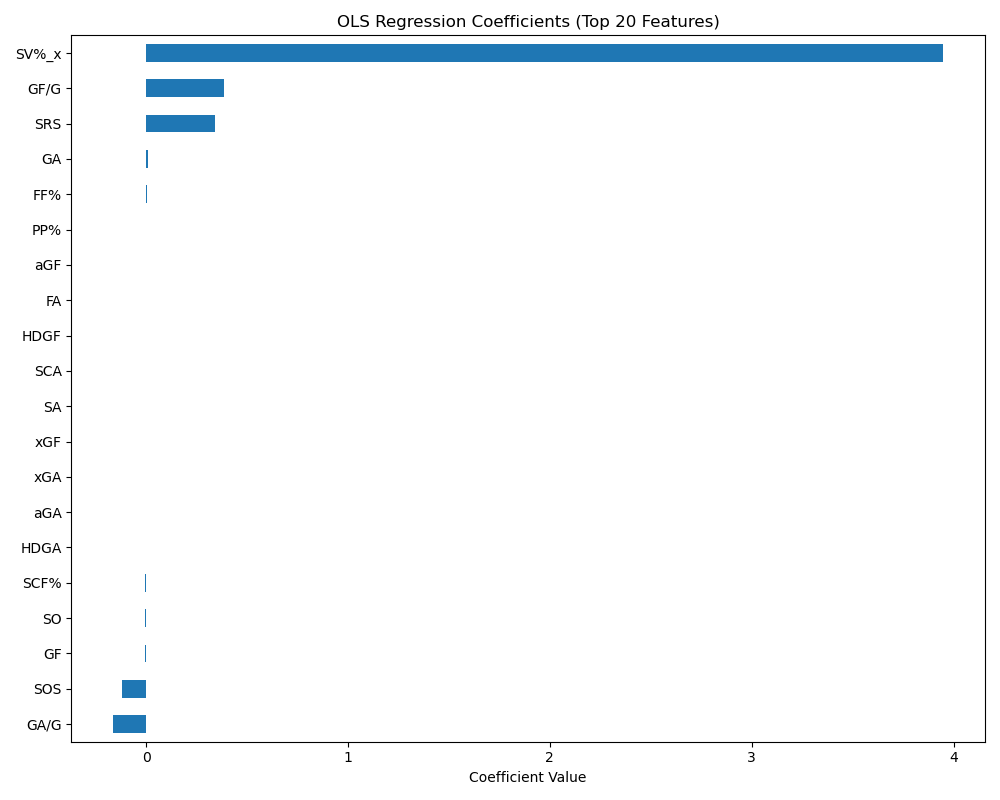

In [10]:
X_const = sm.add_constant(predictors)
model   = sm.OLS(y, X_const).fit()
coef    = model.params.drop("const")

print(model.summary())

fig, ax = plt.subplots(figsize=(10, 8))
coef.sort_values().plot(kind="barh", ax=ax)
ax.set_title("OLS Regression Coefficients (Top 20 Features)")
ax.set_xlabel("Coefficient Value")
plt.tight_layout()
plt.savefig("OLS_Regression_Coefficients.png", dpi=300)
plt.show()


                            OLS Regression Results                            
Dep. Variable:                  W_pct   R-squared:                       0.992
Model:                            OLS   Adj. R-squared:                  0.979
Method:                 Least Squares   F-statistic:                     75.83
Date:                Wed, 04 Mar 2026   Prob (F-statistic):           1.10e-09
Time:                        00:13:05   Log-Likelihood:                 113.54
No. Observations:                  33   AIC:                            -185.1
Df Residuals:                      12   BIC:                            -153.7
Df Model:                          20                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.5529      0.002    246.997      0.0

<Axes: ylabel='Variable'>

Text(0.5, 1.0, 'Standardized Feature Importance (|T-stat|) — Top 20 Features')

Text(0.5, 0, 'Absolute T Statistic')

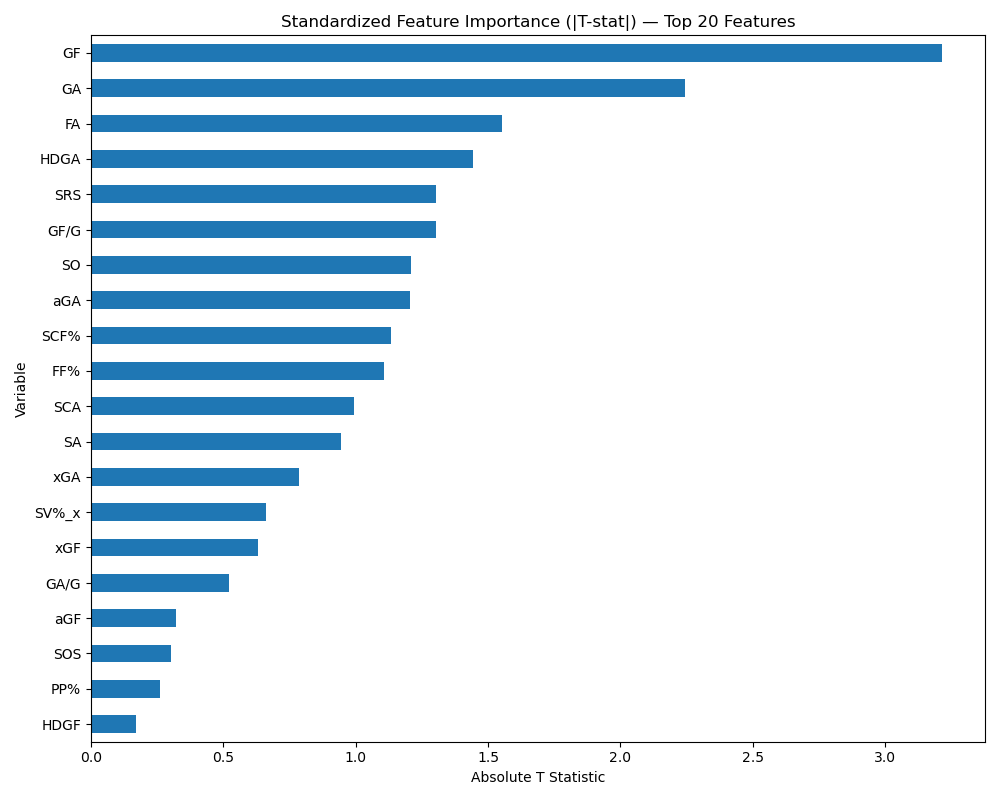

In [11]:
scaler   = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(predictors), columns=predictors.columns)

std_model = sm.OLS(y, sm.add_constant(X_scaled)).fit()

reg_results = pd.DataFrame({
    "Variable": X_scaled.columns,
    "T_stat":   std_model.tvalues[1:]
})
reg_results["Abs_T"] = reg_results["T_stat"].abs()

print(std_model.summary())

fig, ax = plt.subplots(figsize=(10, 8))
reg_results.set_index("Variable")["Abs_T"].sort_values().plot(kind="barh", ax=ax)
ax.set_title("Standardized Feature Importance (|T-stat|) — Top 20 Features")
ax.set_xlabel("Absolute T Statistic")
plt.tight_layout()
plt.savefig("Standardized_Feature_Importance.png", dpi=300)
plt.show()


<Figure size 1000x800 with 0 Axes>

<Axes: >

Text(0.5, 1.0, 'Top 20 Features by Borda Ranking (Lower Score = More Important)')

Text(0.5, 0, 'Borda Score')

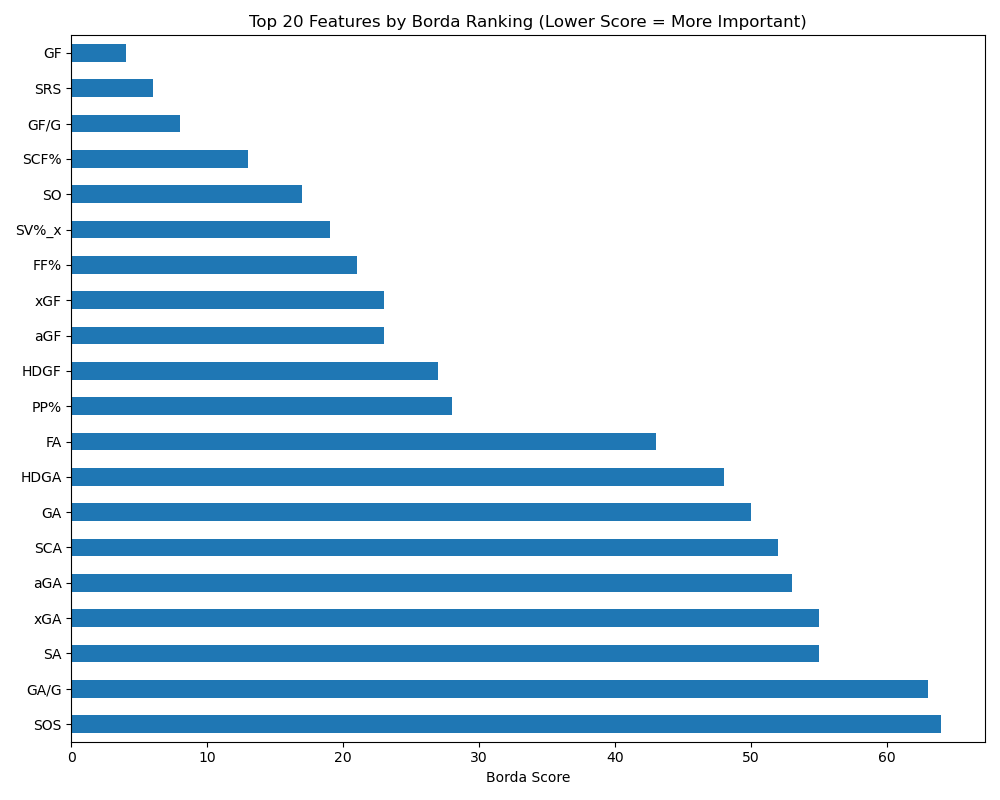

Top 10 most important features:
       Corr_Rank  Reg_Rank  Borda_Score
GF           3.0       1.0          4.0
SRS          1.0       5.0          6.0
GF/G         2.0       6.0          8.0
SCF%         4.0       9.0         13.0
SO          10.0       7.0         17.0
SV%_x        5.0      14.0         19.0
FF%         11.0      10.0         21.0
xGF          8.0      15.0         23.0
aGF          6.0      17.0         23.0
HDGF         7.0      20.0         27.0


In [12]:
win_corr_clean = win_corr.dropna()
corr_rank      = win_corr_clean.rank(ascending=False)
reg_rank       = reg_results.set_index("Variable")["Abs_T"].rank(ascending=False)

borda_df = pd.DataFrame({"Corr_Rank": corr_rank, "Reg_Rank": reg_rank}).dropna()
borda_df["Borda_Score"] = borda_df["Corr_Rank"] + borda_df["Reg_Rank"]
borda_df = borda_df.sort_values("Borda_Score")

plt.figure(figsize=(10, 8))
borda_df.head(20)["Borda_Score"].sort_values(ascending=False).plot(kind="barh")
plt.title("Top 20 Features by Borda Ranking (Lower Score = More Important)")
plt.xlabel("Borda Score")
plt.tight_layout()
plt.savefig("Top_20_Features_by_Borda_Ranking.png", dpi=300)
plt.show()

print("Top 10 most important features:")
print(borda_df.head(10))

In [13]:
# Per-season Borda ranks
# Uses nhl_seasons so we rank within each season, then average across seasons

OFF_METRICS = {
    "GF/GP":  True,
    "SF/GP":  True,
    "SCF%":   True,
    "HDCF%":  True,
    "xGF%":   True,
    "PDO":    True,
    "PP%":    True,
}
DEF_METRICS = {
    "GA/GP":  False,
    "SA/GP":  False,
    "PK%":    True,
}

def rank_metric(series, higher_better):
    return series.rank(ascending=not higher_better, method="min")

season_df = nhl_seasons.copy()

for col, hb in OFF_METRICS.items():
    if col in season_df.columns:
        season_df[f"rk_{col}"] = season_df.groupby("Season")[col].transform(
            lambda s, hb=hb: rank_metric(s, hb))

for col, hb in DEF_METRICS.items():
    if col in season_df.columns:
        season_df[f"rk_{col}"] = season_df.groupby("Season")[col].transform(
            lambda s, hb=hb: rank_metric(s, hb))

off_rk_cols = [f"rk_{c}" for c in OFF_METRICS if f"rk_{c}" in season_df.columns]
def_rk_cols = [f"rk_{c}" for c in DEF_METRICS if f"rk_{c}" in season_df.columns]

print("Offense rank cols:", off_rk_cols)
print("Defense rank cols:", def_rk_cols)

season_df["Off_Borda_Score"]      = season_df[off_rk_cols].mean(axis=1)
season_df["Def_Borda_Score"]      = season_df[def_rk_cols].mean(axis=1)
season_df["Combined_Borda_Score"] = season_df[["Off_Borda_Score", "Def_Borda_Score"]].mean(axis=1)

nhl_cross = season_df.groupby("Team").agg(
    Seasons_Played       = ("Season",               "nunique"),
    Avg_W_pct            = ("W_pct",                "mean"),
    Avg_Combined_Borda   = ("Combined_Borda_Score",  "mean"),
    Combined_Borda_StdDev= ("Combined_Borda_Score",  "std"),
).reset_index()

nhl_cross["Avg_W_pct"]             = nhl_cross["Avg_W_pct"] * 100
nhl_cross["Combined_Borda_StdDev"] = nhl_cross["Combined_Borda_StdDev"].fillna(0)

nhl_cross["Overall_Combined_Rank"] = nhl_cross["Avg_Combined_Borda"].rank(
    ascending=True, method="min").astype(int)
nhl_cross["Consistency_Rank"] = (
    nhl_cross["Combined_Borda_StdDev"]
    .replace(0, np.nan)
    .rank(ascending=True, method="min", na_option="bottom")
    .astype(int)
)

df = nhl_cross.copy()
print(f"\nTeams in power ranking: {len(df)}")
df.head()

Offense rank cols: ['rk_SCF%', 'rk_PDO', 'rk_PP%']
Defense rank cols: ['rk_PK%']

Teams in power ranking: 33


,Team,Seasons_Played,Avg_W_pct,Avg_Combined_Borda,Combined_Borda_StdDev,Overall_Combined_Rank,Consistency_Rank
0,Anaheim Ducks,5,40.971254,24.200000,6.233200,33,26
1,Arizona Coyotes,4,43.151132,21.625000,5.496421,27,20
2,Boston Bruins,5,65.108885,11.833333,7.034637,6,29
3,Buffalo Sabres,5,46.729094,21.566667,2.344023,26,5
4,Calgary Flames,5,56.284843,14.033333,5.766763,13,23


All teams mapped
Fetching NHL team logos...


(np.float64(0.0), np.float64(1.0), np.float64(0.0), np.float64(1.0))

0

0

0

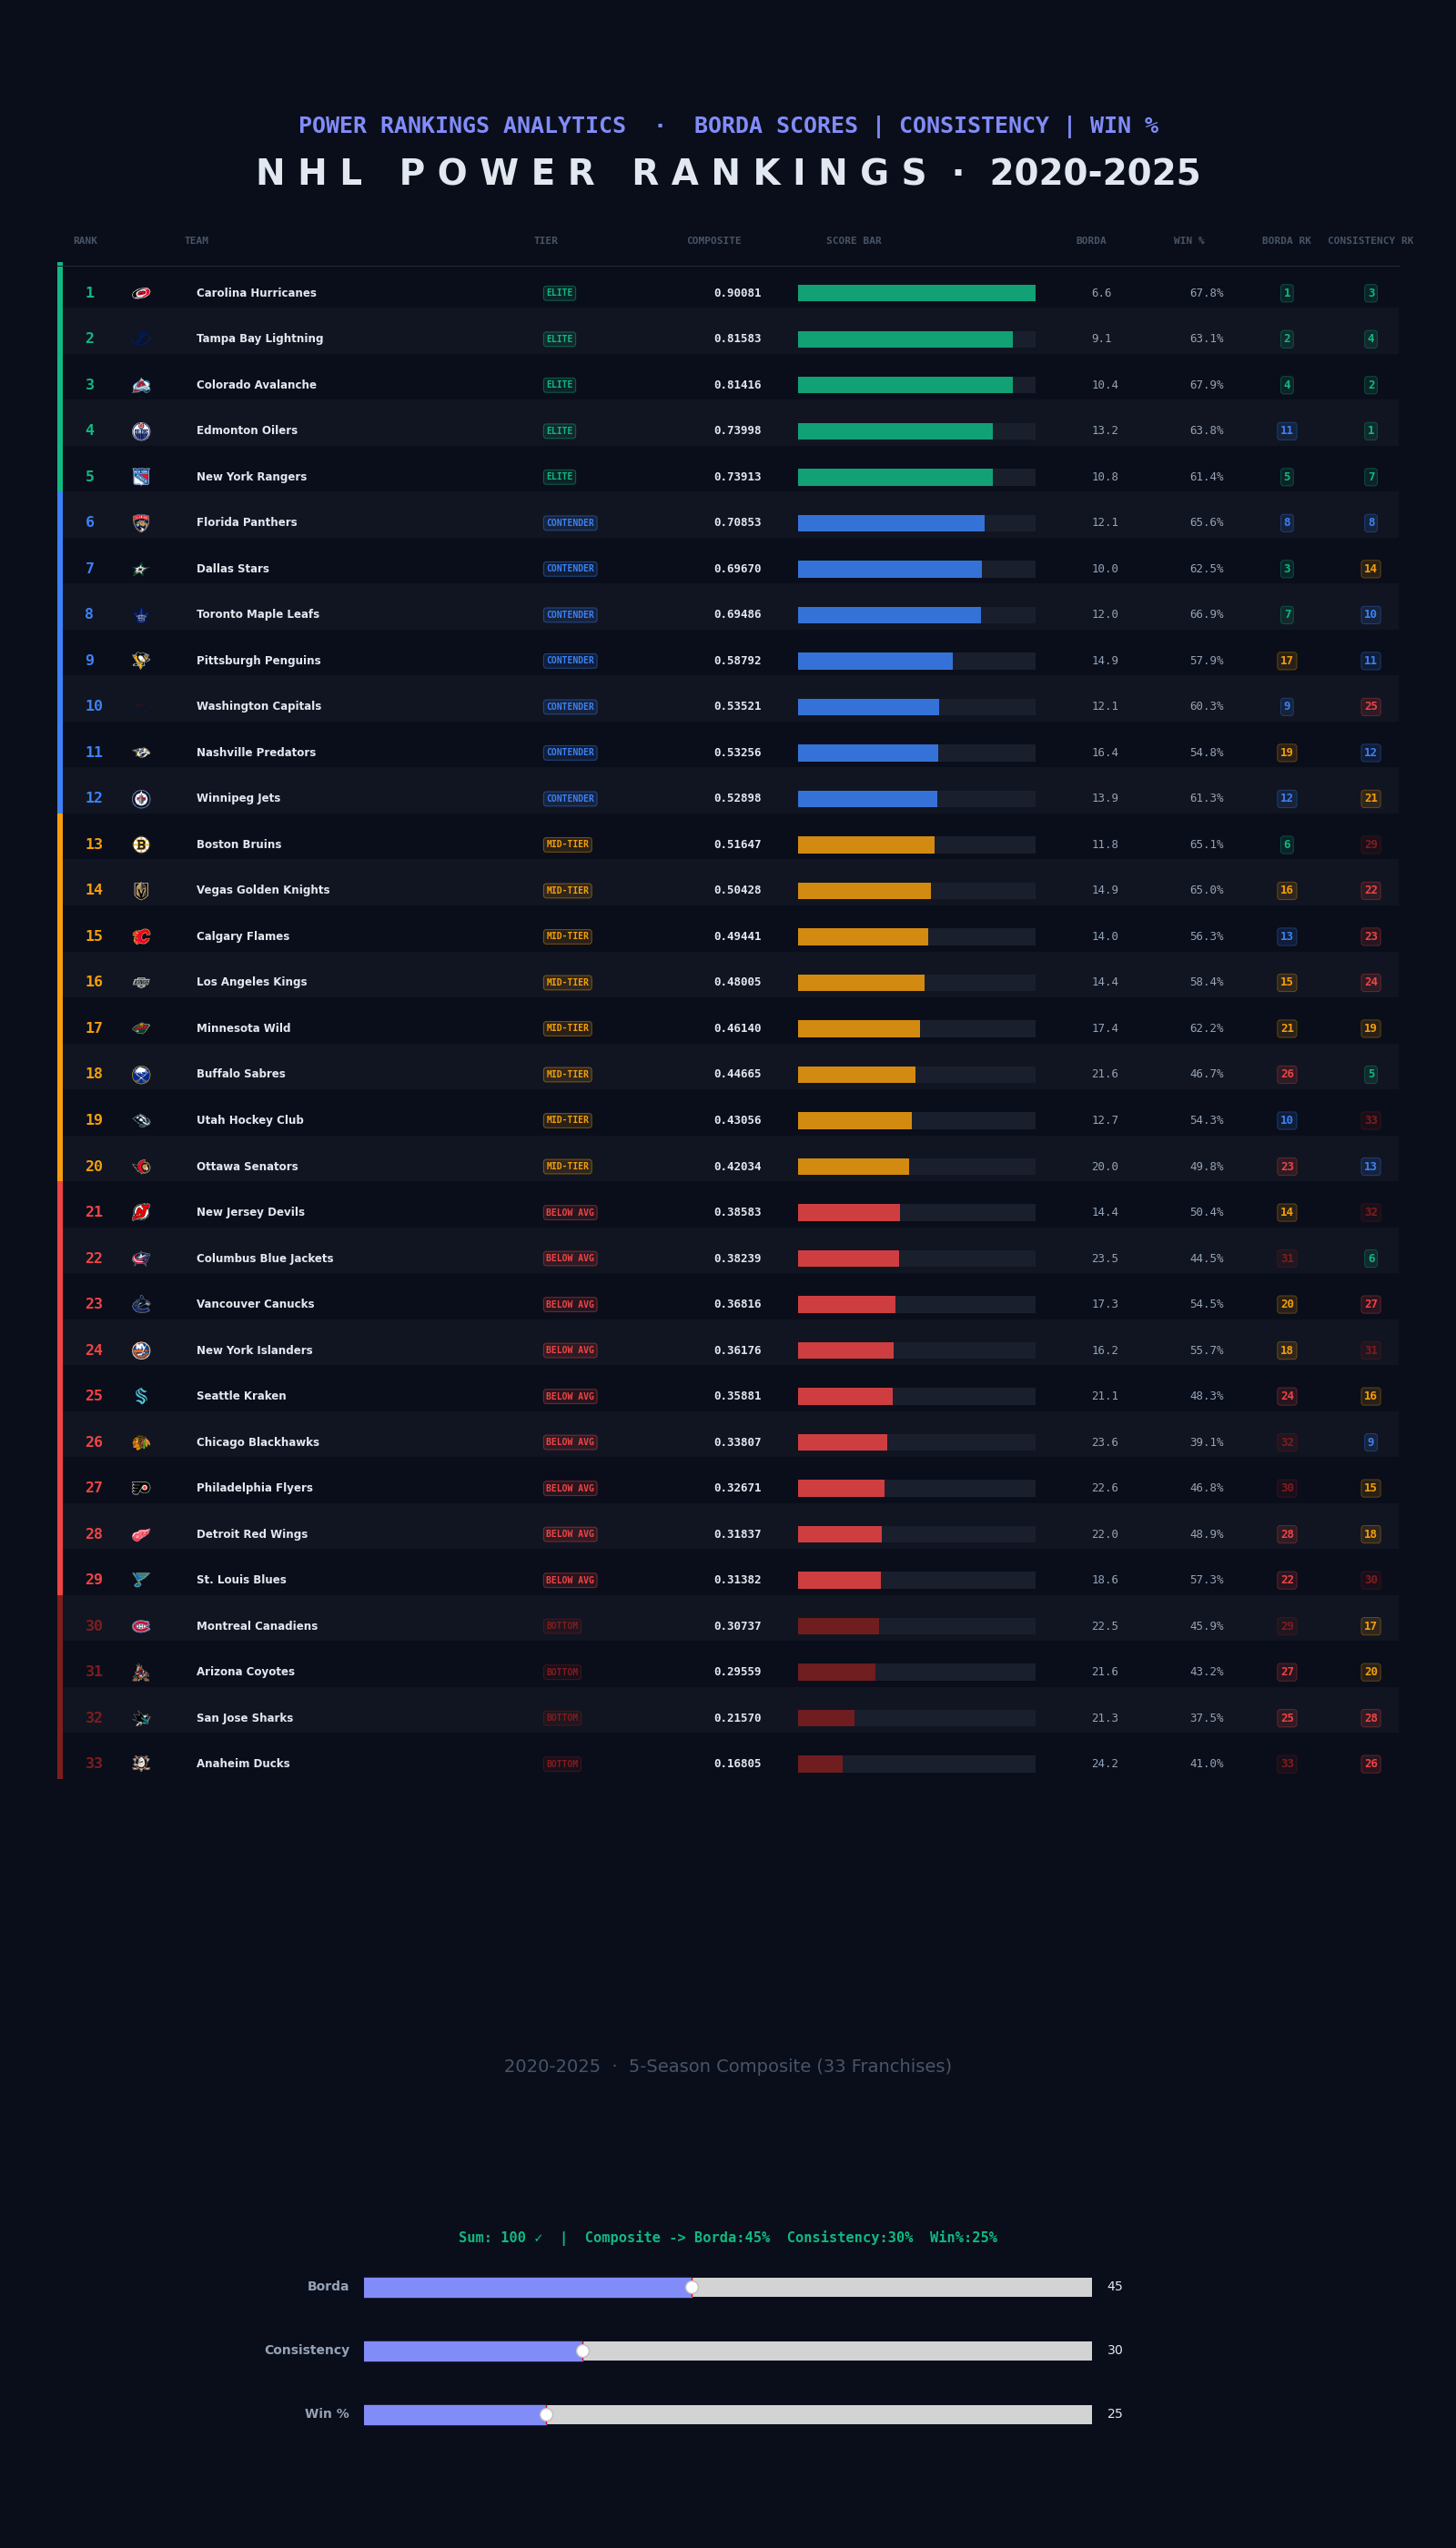

In [14]:
abbr_map = {
    "Anaheim Ducks":         "ana",
    "Arizona Coyotes":       "ari",
    "Boston Bruins":         "bos",
    "Buffalo Sabres":        "buf",
    "Calgary Flames":        "cgy",
    "Carolina Hurricanes":   "car",
    "Chicago Blackhawks":    "chi",
    "Colorado Avalanche":    "col",
    "Columbus Blue Jackets": "cbj",
    "Dallas Stars":          "dal",
    "Detroit Red Wings":     "det",
    "Edmonton Oilers":       "edm",
    "Florida Panthers":      "fla",
    "Los Angeles Kings":     "la",
    "Minnesota Wild":        "min",
    "Montreal Canadiens":    "mtl",
    "Nashville Predators":   "nsh",
    "New Jersey Devils":     "nj",
    "New York Islanders":    "nyi",
    "New York Rangers":      "nyr",
    "Ottawa Senators":       "ott",
    "Philadelphia Flyers":   "phi",
    "Pittsburgh Penguins":   "pit",
    "San Jose Sharks":       "sj",
    "Seattle Kraken":        "sea",
    "St. Louis Blues":       "stl",
    "Tampa Bay Lightning":   "tb",
    "Toronto Maple Leafs":   "tor",
    "Utah Hockey Club":      "utah",
    "Vancouver Canucks":     "van",
    "Vegas Golden Knights":  "vgk",
    "Washington Capitals":   "wsh",
    "Winnipeg Jets":         "wpg",
}

team_colors = {
    "ana": "#FC4C02", "ari": "#8C2633", "bos": "#FFB81C",
    "buf": "#003087", "cgy": "#C8102E", "car": "#CC0000",
    "chi": "#CF0A2C", "col": "#6F263D", "cbj": "#002654",
    "dal": "#006847", "det": "#CE1126", "edm": "#FF4C00",
    "fla": "#041E42", "la":  "#111111", "min": "#154734",
    "mtl": "#AF1E2D", "nsh": "#FFB81C", "nj":  "#CE1126",
    "nyi": "#00539B", "nyr": "#0038A8", "ott": "#C52032",
    "phi": "#F74902", "pit": "#FCB514", "sj":  "#006D75",
    "sea": "#001628", "stl": "#002F87", "tb":  "#002868",
    "tor": "#003E7E", "utah": "#69B3E7", "van": "#00843D",
    "vgk": "#B4975A", "wsh": "#041E42", "wpg": "#004C97",
}

missing = sorted(set(df["Team"]) - set(abbr_map.keys()))
if missing:
    print("Teams missing from abbr_map:", missing)
else:
    print("All teams mapped")

def fetch_logo(abbr, size=28):
    try:
        url = f"https://a.espncdn.com/combiner/i?img=/i/teamlogos/nhl/500/{abbr}.png&h=80&w=80"
        resp = requests.get(url, timeout=5)
        img  = Image.open(BytesIO(resp.content)).convert("RGBA").resize((size, size), Image.LANCZOS)
        return np.array(img)
    except:
        return None

print("Fetching NHL team logos...")
logos = {abbr: fetch_logo(abbr) for abbr in abbr_map.values()}

n_teams     = len(df)
min_borda   = df["Avg_Combined_Borda"].min()
max_borda   = df["Avg_Combined_Borda"].max()
max_consist = df["Consistency_Rank"].max()

def compute_composite(row, weights):
    norm_borda   = 1 - (row["Avg_Combined_Borda"] - min_borda) / (max_borda - min_borda)
    norm_consist = 1 - (row["Consistency_Rank"] - 1) / (max_consist - 1)
    norm_wpct    = row["Avg_W_pct"] / 100
    return round(
        norm_borda   * weights["borda"] +
        norm_consist * weights["consistency"] +
        norm_wpct    * weights["win_pct"],
        5
    )

def get_tier(rank, total):
    if rank <= 5:         return ("ELITE",     "#10b981")
    if rank <= 12:        return ("CONTENDER", "#3b82f6")
    if rank <= 20:        return ("MID-TIER",  "#f59e0b")
    if rank <= total - 4: return ("BELOW AVG", "#ef4444")
    return                       ("BOTTOM",    "#7f1d1d")

fig = plt.figure(figsize=(16, 28))
fig.patch.set_facecolor("#0a0e1a")
ax  = fig.add_axes([0.02, 0.11, 0.96, 0.82])
ax.set_facecolor("#0a0e1a")
ax.axis("off")

slider_color = "#1e293b"
active_color = "#818cf8"
ax_borda   = fig.add_axes([0.25, 0.095, 0.50, 0.015], facecolor=slider_color)
ax_consist = fig.add_axes([0.25, 0.070, 0.50, 0.015], facecolor=slider_color)
ax_wpct    = fig.add_axes([0.25, 0.045, 0.50, 0.015], facecolor=slider_color)
s_borda    = Slider(ax_borda,   "Borda",       0, 100, valinit=45, valstep=1, color=active_color)
s_consist  = Slider(ax_consist, "Consistency", 0, 100, valinit=30, valstep=1, color=active_color)
s_wpct     = Slider(ax_wpct,    "Win %",       0, 100, valinit=25, valstep=1, color=active_color)

for s in [s_borda, s_consist, s_wpct]:
    s.label.set_color("#94a3b8")
    s.label.set_fontsize(10)
    s.label.set_fontweight("bold")
    s.valtext.set_color("#e2e8f0")
    s.valtext.set_fontsize(10)

weight_text = fig.text(0.50, 0.120, "", ha="center", fontsize=11,
                       fontweight="bold", fontfamily="monospace")

def update(val=None):
    ax.clear()
    ax.set_facecolor("#0a0e1a")
    ax.axis("off")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

    raw_b, raw_c, raw_w = s_borda.val, s_consist.val, s_wpct.val
    total = raw_b + raw_c + raw_w
    if total == 0:
        weights = {"borda": 1/3, "consistency": 1/3, "win_pct": 1/3}
        total = 100
    else:
        weights = {"borda": raw_b/total, "consistency": raw_c/total, "win_pct": raw_w/total}

    warn = "!" if abs(total - 100) > 0.5 else "✓"
    borda_pct   = f'{weights["borda"]:.0%}'
    consist_pct = f'{weights["consistency"]:.0%}'
    wpct_pct    = f'{weights["win_pct"]:.0%}'
    weight_text.set_text(
        f"Sum: {int(total)} {warn}  |  "
        f"Composite -> Borda:{borda_pct}  Consistency:{consist_pct}  Win%:{wpct_pct}")
    weight_text.set_color("#10b981" if abs(total - 100) < 1 else "#f59e0b")

    df["Composite"] = df.apply(compute_composite, axis=1, weights=weights)
    ranked = df.sort_values("Composite", ascending=False).reset_index(drop=True)
    ranked["Power_Rank"] = range(1, n_teams + 1)
    max_comp = ranked["Composite"].max()

    row_h    = 0.022
    header_y = 0.970
    start_y  = header_y - 0.025

    ax.text(0.5, 1.03, "POWER RANKINGS ANALYTICS  ·  BORDA SCORES | CONSISTENCY | WIN %",
            transform=ax.transAxes, ha="center", va="top", fontsize=18,
            fontweight="bold", color="#818cf8", fontfamily="monospace")
    ax.text(0.5, 1.01, "N H L   P O W E R   R A N K I N G S  ·  2020-2025",
            transform=ax.transAxes, ha="center", va="top", fontsize=28,
            fontweight="bold", color="#e2e8f0")
    ax.text(0.5, 0.100, "2020-2025  ·  5-Season Composite (33 Franchises)",
            transform=ax.transAxes, ha="center", va="top", fontsize=14, color="#475569")

    cols = {
        "rank": 0.04, "logo": 0.08, "team": 0.12, "tier": 0.37,
        "composite": 0.49, "bar_start": 0.55, "bar_end": 0.72,
        "borda": 0.76, "wpct": 0.83, "borda_rk": 0.90, "consist_rk": 0.96
    }
    for x, label in [
        (cols["rank"],           "RANK"),
        (cols["team"],           "TEAM"),
        (cols["tier"],           "TIER"),
        (cols["composite"],      "COMPOSITE"),
        (cols["bar_start"]+0.04, "SCORE BAR"),
        (cols["borda"],          "BORDA"),
        (cols["wpct"],           "WIN %"),
        (cols["borda_rk"],       "BORDA RK"),
        (cols["consist_rk"],     "CONSISTENCY RK"),
    ]:
        ax.text(x, header_y, label, ha="center", transform=ax.transAxes,
                fontsize=8, fontweight="bold", color="#475569",
                fontfamily="monospace", va="center")

    ax.plot([0.02, 0.98], [header_y - 0.012]*2,
            transform=ax.transAxes, color="#1e293b", linewidth=0.8)

    for i, (_, row) in enumerate(ranked.iterrows()):
        y_pos = start_y - i * row_h
        tm    = row["Team"]
        abbr  = abbr_map.get(tm)
        tier_label, tier_color = get_tier(row["Power_Rank"], n_teams)

        if i % 2 == 1:
            ax.add_patch(plt.Rectangle(
                (0.02, y_pos - row_h/2 + 0.004), 0.96, row_h,
                transform=ax.transAxes, facecolor="#ffffff08", edgecolor="none", zorder=0))

        ax.add_patch(plt.Rectangle(
            (0.02, y_pos - row_h/2 + 0.004), 0.004, row_h,
            transform=ax.transAxes, facecolor=tier_color, edgecolor="none", zorder=1))

        ax.text(cols["rank"], y_pos, str(row["Power_Rank"]),
                transform=ax.transAxes, fontsize=12, fontweight="bold",
                color=tier_color, va="center", fontfamily="monospace")

        if abbr and logos.get(abbr) is not None:
            im = OffsetImage(logos[abbr], zoom=0.55)
            ax.add_artist(AnnotationBbox(im, (cols["logo"], y_pos),
                          xycoords="axes fraction", frameon=False, box_alignment=(0.5, 0.5)))

        ax.text(cols["team"], y_pos, tm, transform=ax.transAxes,
                fontsize=8.5, fontweight="bold", color="#e2e8f0", va="center")

        bp = dict(boxstyle="round,pad=0.3",
                  facecolor=tier_color+"22", edgecolor=tier_color+"66", linewidth=0.8)
        ax.text(cols["tier"], y_pos, tier_label, transform=ax.transAxes,
                fontsize=7, fontweight="bold", color=tier_color,
                va="center", bbox=bp, fontfamily="monospace")

        comp_str = f'{row["Composite"]:.5f}'
        ax.text(cols["composite"], y_pos, comp_str,
                transform=ax.transAxes, fontsize=9, fontweight="bold",
                color="#e2e8f0", va="center", fontfamily="monospace")

        bw = (cols["bar_end"] - cols["bar_start"]) * (row["Composite"] / max_comp) if max_comp > 0 else 0
        ax.add_patch(plt.Rectangle(
            (cols["bar_start"], y_pos - 0.004), cols["bar_end"] - cols["bar_start"], 0.008,
            transform=ax.transAxes, facecolor="#1a1f2e", edgecolor="none", zorder=1))
        ax.add_patch(plt.Rectangle(
            (cols["bar_start"], y_pos - 0.004), bw, 0.008,
            transform=ax.transAxes, facecolor=tier_color, edgecolor="none", zorder=2, alpha=0.85))

        borda_str = f'{row["Avg_Combined_Borda"]:.1f}'
        wpct_str  = f'{row["Avg_W_pct"]:.1f}%'
        ax.text(cols["borda"], y_pos, borda_str,
                transform=ax.transAxes, fontsize=9, color="#94a3b8",
                va="center", fontfamily="monospace")
        ax.text(cols["wpct"], y_pos, wpct_str,
                transform=ax.transAxes, fontsize=9, color="#94a3b8",
                va="center", fontfamily="monospace")

        for cx, v in [(cols["borda_rk"], row["Overall_Combined_Rank"]),
                      (cols["consist_rk"], row["Consistency_Rank"])]:
            p  = (n_teams - v) / (n_teams - 1)
            bc = ("#10b981" if p > 0.8 else "#3b82f6" if p > 0.6
                  else "#f59e0b" if p > 0.35 else "#ef4444" if p > 0.15 else "#7f1d1d")
            ax.text(cx, y_pos, str(int(v)), transform=ax.transAxes,
                    fontsize=9, fontweight="bold", color=bc, va="center", ha="center",
                    bbox=dict(boxstyle="round,pad=0.25",
                              facecolor=bc+"22", edgecolor=bc+"55", linewidth=0.7),
                    fontfamily="monospace")

    fig.canvas.draw_idle()

s_borda.on_changed(update)
s_consist.on_changed(update)
s_wpct.on_changed(update)
update()
plt.show()